<a href="https://colab.research.google.com/github/apranav22/bayesian_nmor/blob/main/toy_bayesian_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

True B value = -0.8525836849469883


Text(0, 0.5, 'Measured alpha')

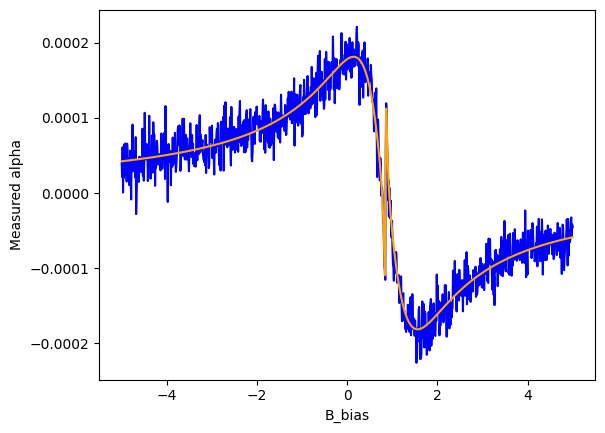

In [1]:
import numpy as np
import time
import cupy as cp
import matplotlib.pyplot as plt
import os
import sys
from scipy.stats import norm
from scipy.integrate import simpson
global tou, delta, k2, transit_rate, lo

# spontaneous emission rate ~ 10^7 Hz
tou = 10**7
# detuning
delta = 0.1 * tou
# saturation parameter
k2 = 5.0
# transit rate
transit_rate = 0.01 * tou
# unsaturated absorption length
lo = 0.001

folder_path = r"C:\Users\Dinesh\UGP"
sys.path.insert(0, folder_path)

def alpha_th(B_tot):
    # gyromagnetic ratio ~ 10^6 Hz/Guass, larmor freq
    gyro = 1e7
    omega_l = gyro * (B_tot)
    D = (
        8
        * (omega_l**2)
        * (
            (32 * (tou**2) * (k2 + 3) * ((omega_l**2) + (delta**2)))
            + (192 * (((delta**2) - (omega_l**2)) ** 2))
            + ((tou**4) * (k2 + 2) * (k2 + 6))
        )
    ) + (
        2
        * (transit_rate**2)
        * (((tou**2) * ((2 * k2) + 3)) + (12 * (delta**2)))
        * (((tou**2) * ((k2 + 2) ** 2)) + (16 * (delta**2)))
    )
    alpha_th = (
        -6
        * tou
        * omega_l
        * (
            (
                8
                * (omega_l**2)
                * ((8 * (omega_l**2)) + ((tou**2) * (k2 + 2)) - (8 * (delta**2)))
            )
            + (
                transit_rate
                * (
                    (4 * transit_rate * ((tou**2) - ((2 * delta) ** 2)))
                    - ((tou**3) * k2 * (k2 + 2))
                )
            )
        )
        / D
    )
    return lo * alpha_th


def alpha_exp(alpha_th, sigma):
    return (alpha_th + np.random.normal(0, sigma, size=alpha_th.shape))

B_unk = np.random.uniform(-1, 1) #B_unknown can be anything between -2 and 2
print("True B value =", B_unk)
gamma = 0.02
sigma = 2e-5 #FIXME: This is not a percentage but an absolute value

B_bias = np.linspace(-5, 5, 1000)
B_tot = B_unk + B_bias

alpha_vals = alpha_th(B_tot)


alpha_exp_vals = alpha_exp(alpha_vals, sigma)
plt.figure()
plt.plot(B_bias, alpha_exp_vals, color="blue")
plt.plot(B_bias, alpha_vals, color="orange")
plt.xlabel("B_bias")
plt.ylabel("Measured alpha")

Frequentist Scheme:

1.   An experiment corresponds to a fixed Bias and measuring Alpha as a signal against time. We then obtain an averaged Alpha for the same.
2.   We then do a field scan, an dobtain a graph of alpha against Bias (which by itself is costly because we ARE PHYSICALLY doing those many experiment)
3. then we  simple fir the model that minimises least square loss

In [ ]:
def MLE(B_unk, B_bias,  sigma = 2e-5, Test = 0, num_samples = 10):    
    B_tot = B_unk + B_bias
    alpha_vals = alpha_th(B_tot)
    alpha_exp_vals = alpha_exp(alpha_vals, sigma)
    indices = np.where(alpha_vals <= 1e-21)
    #I've made this change so that the points are somewhat uniformly sampled around the sensitive points and not randomly at the tails
    i = indices[0][0]
    samples = np.random.uniform(i - (B_bias.size//4), i+(B_bias.size//4), num_samples) 
    samples = np.round(samples).astype(int)
    B_bias_samples = B_bias[samples]
    alpha_vals_exp_samples = alpha_exp_vals[samples]
    plt.plot(B_bias, alpha_vals, label="Theoretical Curve", color="orange")
    plt.scatter(B_bias_samples, alpha_vals_exp_samples, label="Sampled Data", color="red")
    from scipy.optimize import curve_fit
    def alpha_model(B_total, B_unk_fit):
        B_tot_fit = B_unk_fit + B_total
        return alpha_th(B_tot_fit)
    initial_guess = [0.0, ]
    popt, pcov = curve_fit(
        alpha_model,
        B_bias_samples,
        alpha_vals_exp_samples,
        p0=initial_guess,
    )
    B_est_MLE = popt[0]
    print(popt[0], '+-', pcov[0][0]**0.5,  'is the estimated value of B_unk, and the true value is', B_unk)

    new_dir = "C:/Users/Dinesh/UGP/Tests/Toy_Model/Test_{Test}".format(Test=Test)
    os.makedirs(new_dir, exist_ok=True)
    save_path = os.path.join(new_dir, f'MLE Output for True B{Test}.png'.format(Test))
    plt.plot(B_bias, alpha_model(B_bias, *popt), color="green", linestyle="--", label="Fitted Curve")
    plt.xlabel("B_bias")
    plt.ylabel("Measured alpha")
    plt.title("MLE Output for True B:"+ str(popt[0])+"+-"+ str(pcov[0][0]**0.5))
    plt.legend()
    plt.savefig(save_path)
    return popt[0], pcov[0][0]**0.5

Bayesian Code Begins here

1. As of now, we have set a uniform grid, we could try a non uniform grid for better numerical integration

In [ ]:
def alpha_theory(B_tot):
    return alpha_th(B_tot)

#plt.plot(B_bias,alpha_theory(B_tot), label='alpha_theory')

# likelihood for cp and also actual expression
def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05, Gamma=1.0):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total)
    #prefactor = 1.0 / (sigma * cp.sqrt(2 * np.pi))
    exponent = -((alpha_meas - alpha_exp)**2) / (2 * sigma**2)

    return cp.exp(exponent)

#zoom function
def adaptive_zoom(posterior, B_grid, n_grid_fixed = 500, zoom_factor = 5):
    #note: now anything outside our zoomed interval has been set to zero, we have reduced variance artificailly beyong the analytical variance but
    #i don't think its a problem because for any confidence interval quote we are  going to be giving probablity confidencee of 60% type anyhow, so tis alright
    #but still think about it more FIXME

    #cumulative ditribution function, ignoring dB factor coz we are going to normalise anyhow
    cdf = cp.cumsum(posterior)
    cdf /= cdf[-1]

    #if nearly 99% of probability is in too small a region, we are going to trigger a zoom FIXME: Hyperparameter, can be tuned
    idx_start = int(cp.searchsorted(cdf, cp.array(0.01)))
    idx_end = int(cp.searchsorted(cdf, cp.array(0.99)))

    points_with_actual_probability = idx_end - idx_start

    #FIXME: this ratio threshold is also a hyperparameter
    if points_with_actual_probability/n_grid_fixed > 0.1:
        return posterior, B_grid, False

    #zoom logic

    n_parents_needed=  n_grid_fixed//zoom_factor

    center_idx =(idx_start + idx_end)//2

    half_window = n_parents_needed//2
    parent_start = center_idx - half_window
    parent_end = center_idx + half_window

    if parent_start < 0:
        parent_end += parent_start
        parent_start = 0
        
    if parent_end >= len(B_grid):
        parent_start += len(B_grid) - parent_end - 1
        parent_end = len(B_grid) - 1

    new_B_grid = cp.linspace(B_grid[parent_start], B_grid[parent_end], n_grid_fixed)

    parent_probs = posterior[parent_start:parent_end]

    new_posterior = cp.repeat(parent_probs, zoom_factor)

    new_dB= new_B_grid[1] - new_B_grid[0]
    current_area = cp.sum(new_posterior) * new_dB
    new_posterior /=  current_area

    return new_posterior, new_B_grid, True  

def simpson_gpu(y, x):
    dx = x[1] - x[0]
    n = len(x)
    if n % 2 == 0:
        x = x[:-1]
        y = y[..., :-1]

    # Simpson's 1/3 rule: dx/3 * (y_0 + 4y_1 + 2y_2 + ... + 4y_{n-1} + y_n)
    return dx / 3. * cp.sum(y[..., 0:-1:2] + 4.*y[..., 1::2] + y[..., 2::2], axis=-1)


# Posterior update
def update_posterior(prior, measurements, B_grid, B_bias, sigma=0.05):
    post = prior.copy()
    for alpha_meas in measurements:
        # FASTER: Calculate likelihood for all B_grid points at once
        L = likelihood(alpha_meas, B_grid, B_bias, sigma)
        post *= L

    # normalize
    post_sum = simpson_gpu(post, B_grid)
    if post_sum > 1e-12:
        post /= post_sum
    else:
        # Handle cases where the posterior is effectively zero everywhere
        post = cp.ones_like(B_grid) / (B_grid.max() - B_grid.min())
    return post

# KL Divergence Utility
def expected_KL(B_bias, prior, B_grid, sigma=0.1, n_samples=10**4):
    # Sample possible outcomes (FIXME: this range is still hardcoded and the integration grid is uniform)
    alphas = cp.linspace(-0.1, 0.1, n_samples) #o

    # Shape: (n_samples, n_grid)
    alpha_grid, B_grid_2d = cp.meshgrid(alphas, B_grid, indexing='ij')
    L_matrix = likelihood(alpha_grid, B_grid_2d, B_bias, sigma)

    # Calculate marginal likelihood P(alpha|B_bias) for all alphas at once
    integrand_P_alpha = L_matrix * prior
    P_alpha = simpson_gpu(integrand_P_alpha, B_grid)

    dB = B_grid[1] - B_grid[0]

    # Calculate KL divergence for each alpha
    # The posterior for each alpha is integrand_P_alpha
    norm_factors = P_alpha


    epsilon = 1e-25
    # To avoid division by zero for alphas with zero probability
    valid_indices = norm_factors>0
    if not cp.any(valid_indices):
        return 0.0

    post_matrix = integrand_P_alpha[valid_indices] / norm_factors[valid_indices, cp.newaxis] #what does np.newaxis? FIXME

    ratio = (post_matrix + epsilon) / (prior[cp.newaxis, :] + epsilon)
    ratio[ratio <= 0] = epsilon
    log_ratio = cp.log(ratio)

    # Handle -inf * 0 cases
    KL_integrand = post_matrix * log_ratio * dB
    KL_integrand[cp.isnan(KL_integrand)] = 0.0
    KL_vals = simpson_gpu(KL_integrand, B_grid)

    P_alpha_sum = cp.sum(P_alpha[valid_indices])
    if P_alpha_sum == 0.0:
        return 0.0  # Return 0 if total probability is 0
        
    expected_KL_val = cp.sum(P_alpha[valid_indices] * KL_vals) / P_alpha_sum

    # Calculate the final expected value
    expected_KL_val = cp.sum(P_alpha[valid_indices] * KL_vals) / cp.sum(P_alpha[valid_indices])


    return float(expected_KL_val)

#trying out new hopefully faster expected_kl divergence 
#so it does indeed work and it has made the code faster overall
def get_expected_kl(candidates, B_grid, prior, sigma, n_samples = 10**3,batch_size = 100):

    n_candidates = len(candidates)
    n_grid =len(B_grid)
    dB = B_grid[1] - B_grid[0]  

    expected_KL_values = cp.zeros(n_candidates)

    prior_reshaped = prior.reshape(1,1,n_grid)

    for i in range(0,n_candidates, batch_size):
        end = min(i+batch_size, n_candidates)
        batch_candidates = candidates[i:end]

        B_total_batch = batch_candidates[:,None] + B_grid[None, :]

        A_batch = alpha_theory(B_total_batch)
        #diff_sq =  (A_batch[:,:,None] - A_batch[:,None,:])**2
        alphas = cp.linspace(-0.01, 0.01, n_samples)
        diff_sq = (alphas[None,:,None] - A_batch[:,None,:])**2

        L_tensor = cp.exp(-diff_sq / (2 * sigma**2))
        P_alpha = cp.sum(L_tensor * prior_reshaped, axis=2) * dB
        Posterior_tensor = (L_tensor * prior_reshaped) / (P_alpha[:, :, None] + 1e-15)
        log_term = cp.log((Posterior_tensor + 1e-15) / (prior_reshaped + 1e-15))
        KL_per_meas = cp.sum(Posterior_tensor * log_term, axis=2) * dB
        batch_expected_kl = cp.sum(P_alpha * KL_per_meas, axis=1) * (alphas[1] - alphas[0])
        #batch_expected_kl = cp.sum(P_alpha * KL_per_meas, axis=1)
        expected_KL_values[i:end] = batch_expected_kl
        del L_tensor,Posterior_tensor,diff_sq
        cp.get_default_memory_pool().free_all_blocks()
    
    return expected_KL_values



# Adaptive Bayesian Experiment Loop
def run_experiment(
    N_exp=5, B_true=0.2, sigma_noise = 0.05, sigma=0.05, B_range=(-1, 1), n_grid=1000, candidates = cp.linspace(-1, 1, 5000), Test = 0, Gamma = 1.0
):  # FIXME: Why is b_range (-1,1)?
    
    start_time = time.time()
    
    # Step 1: initialize prior
    B_grid = cp.linspace(B_range[0], B_range[1], n_grid)
    prior = cp.ones_like(B_grid) / (B_range[1] - B_range[0])  # uniform prior
    B_biases = []
    Expected_KL =  []
    Mean, Mode, StdDev = [],[],[]
    posteriors = [prior]
    bgrid = [B_grid.get()]

    for _ in range(N_exp):
        # Step 2: choose bias by maximizing expected KL # FIXME
        
        t_0 = time.time()
        if _ !=0:
            candidates = -B_grid
        t_0_kl = time.time()
        #util_vals = cp.array([expected_KL(b, prior, B_grid, sigma) for b in candidates])
        util_vals = get_expected_kl(candidates, B_grid, prior, sigma, batch_size=100)
        B_bias = candidates[cp.argmax(util_vals)]
        B_biases.append(B_bias)
        Expected_KL.append(float(cp.max(util_vals)))
        t_1_kl = time.time()
        zoomed = False
      
        #code block which creates and saves plots of expected KL vs B_bias for each experiment within directory "Experiment i" - need to do the cp to np conversion
        #to use matplotlib ig - FIXME
        new_dir = "C:/Users/Dinesh/UGP/Tests/Toy_Model/Test_{Test}".format(Test=Test)
        os.makedirs(new_dir, exist_ok=True)
        save_path = os.path.join(new_dir, f'Expected_KL_vs_B_bias_Experment{_+1}.png')
        plt.figure(figsize=(6, 4))
        plt.plot(candidates.get(), util_vals.get(), label="Expected KL divergence as a function of B_Bias")
        plt.xlabel("B_bias")
        plt.ylabel("Expected KL Divergence")
        plt.title("Expected KL vs B_bias for Experiment {i}".format(i=_+1))
        plt.savefig(save_path)


        # Step 3: generate synthetic measurement
        B_total = B_true + B_bias
        alpha_true = alpha_theory(B_total)
        alpha_meas = cp.random.normal(alpha_true, sigma_noise, size=5)  # 5 samples -> Integration time FIXME
        # Step 4: update posterior
        t_0_updation  = time.time()
        posterior = update_posterior(prior, alpha_meas, B_grid, B_bias, sigma)
        if _ != 0:
            posterior, B_grid, zoomed = adaptive_zoom(posterior, B_grid, zoom_factor=5)
        bgrid.append(B_grid.get())
        posteriors.append(posterior)
        mean, mode, stddev = calculate_summary_stats(posterior.get(), B_grid.get())
        Mean += [mean]
        Mode += [mode]
        StdDev += [stddev]
        if zoomed:
            print(f"zoomed in, Range: [{B_grid[0]:.4f},{B_grid[-1]:.4f}]")
            prior = posterior
        else:    
            prior = posterior   
        t_1 = time.time()
        print(f"Experiment {_} took time: {t_1 - t_0}, with Bias Optimisation taking time: {t_1_kl-t_0_kl} and posterior updation and stats calculation taking time: {t_1  - t_0_updation}")
    final_posteriors_cpu = [p.get() for p in posteriors]
    final_biases_cpu = B_biases#.get()
    print(f"The total analysis took time: {time.time() - start_time}")
    return bgrid, final_posteriors_cpu, final_biases_cpu, Expected_KL, Mean, Mode, StdDev

def calculate_summary_stats(posterior, B_grid):
    # Mean
    mean = simpson(B_grid * posterior, B_grid)

    # Mode
    mode_index = np.argmax(posterior)
    mode = B_grid[mode_index]

     # Variance
    variance = simpson(((B_grid - mean)**2) * posterior, B_grid)

    return mean, mode, variance**0.5

Test 4

In [4]:
B_unk = np.random.uniform(-1, 1) #B_unknown can be anything between -2 and 2
print("True B value =", B_unk)
N_exp = 20
Test = 6

True B value = 0.6938545648437355


0.5961415678632649 +- 0.002020411374334392 is the estimated value of B_unk, and the true value is 0.6938545648437355


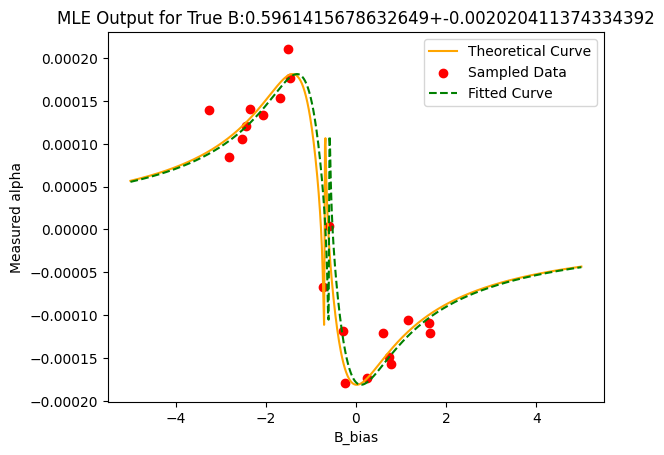

In [5]:
Mean_MLE, StdDev_MLE = MLE(B_unk, B_bias, sigma, Test, num_samples = N_exp)

Experiment 0 took time: 1.6000645160675049, with Bias Optimisation taking time: 1.4130370616912842 and posterior updation and stats calculation taking time: 0.037757158279418945
zoomed in, Range: [0.2753,1.2763]
Experiment 1 took time: 1.2007098197937012, with Bias Optimisation taking time: 1.1242923736572266 and posterior updation and stats calculation taking time: 0.04018068313598633
Experiment 2 took time: 0.30266356468200684, with Bias Optimisation taking time: 0.2664668560028076 and posterior updation and stats calculation taking time: 0.0028841495513916016
Experiment 3 took time: 0.31746745109558105, with Bias Optimisation taking time: 0.2782883644104004 and posterior updation and stats calculation taking time: 0.0029969215393066406
Experiment 4 took time: 0.3163020610809326, with Bias Optimisation taking time: 0.28078341484069824 and posterior updation and stats calculation taking time: 0.0029358863830566406
zoomed in, Range: [0.5922,0.7928]
Experiment 5 took time: 0.31940031051

C:\Users\Dinesh\AppData\Local\Temp\ipykernel_11856\3418680025.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


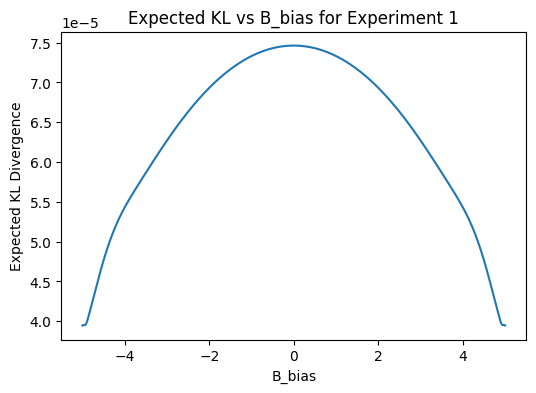

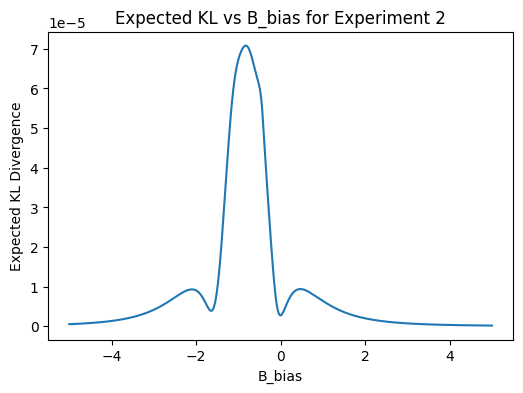

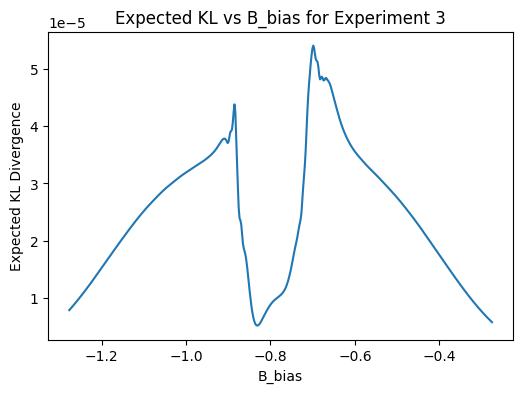

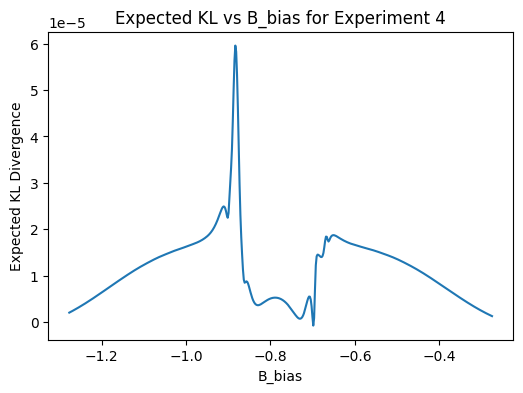

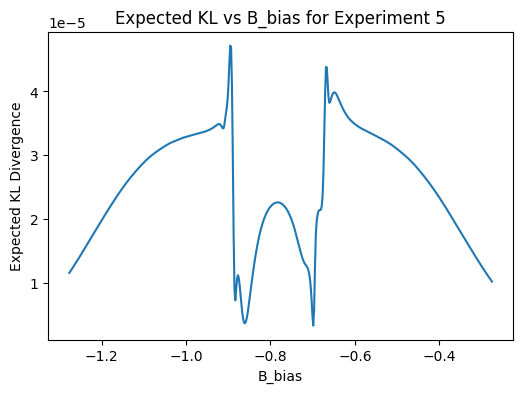

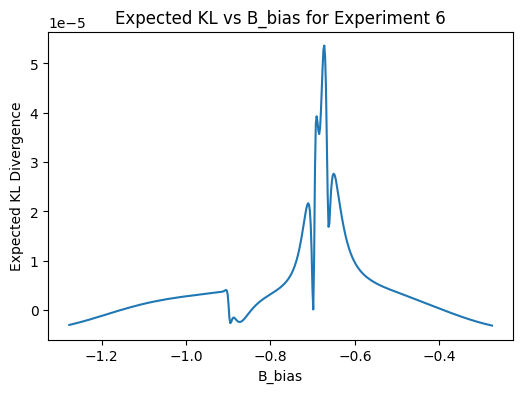

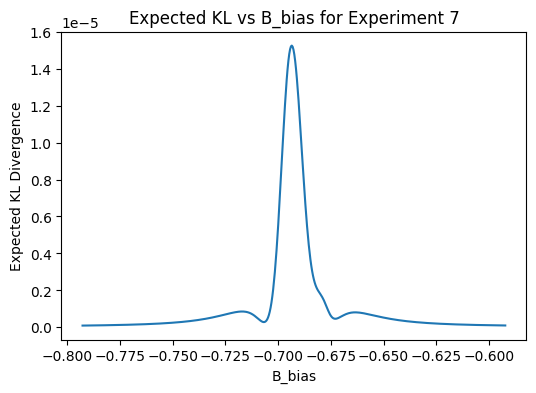

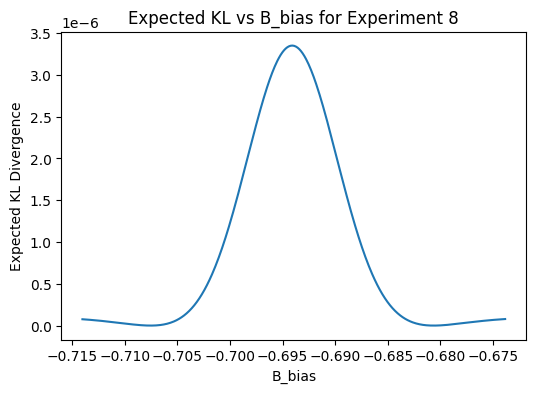

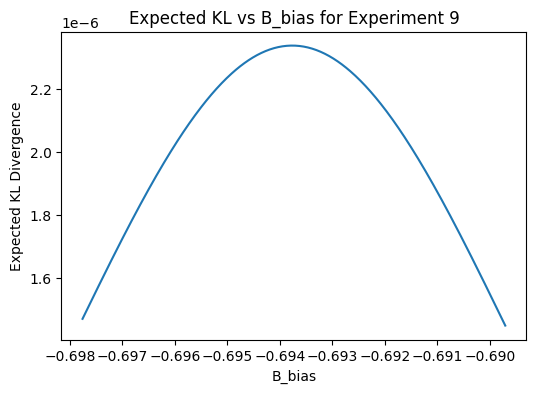

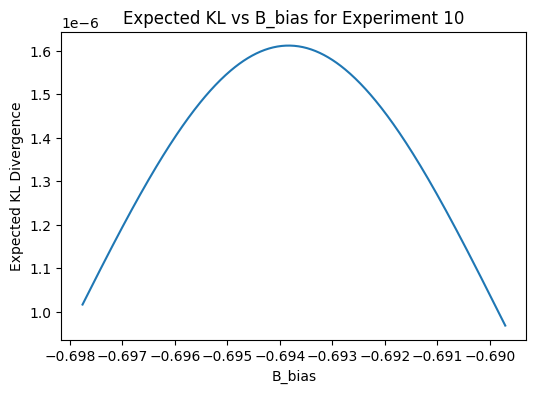

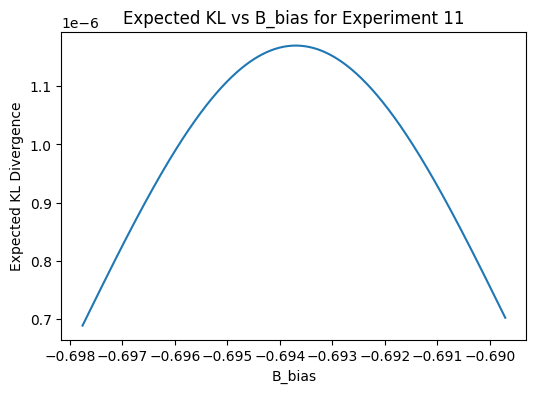

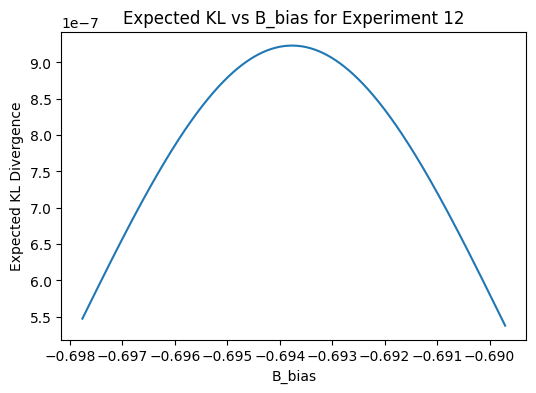

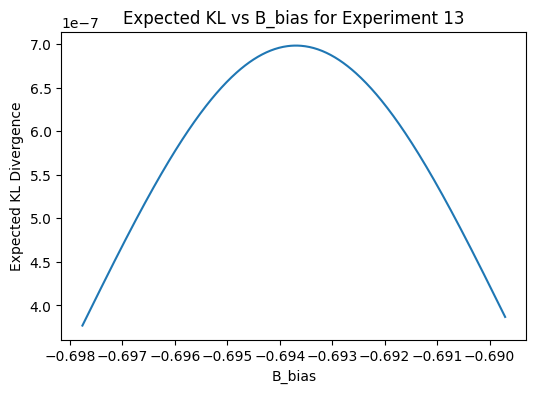

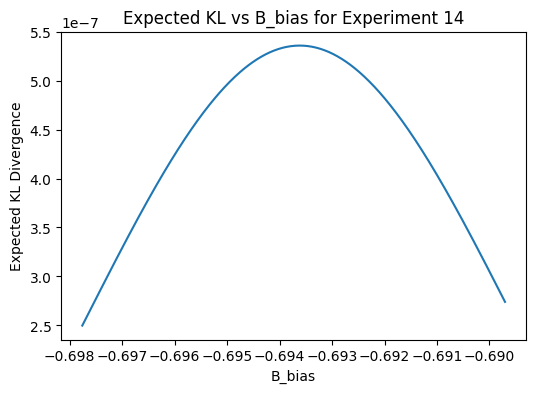

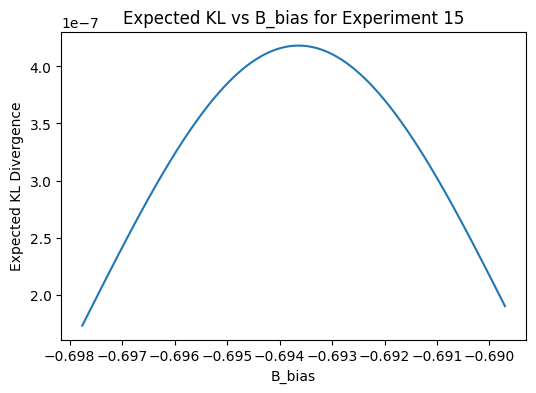

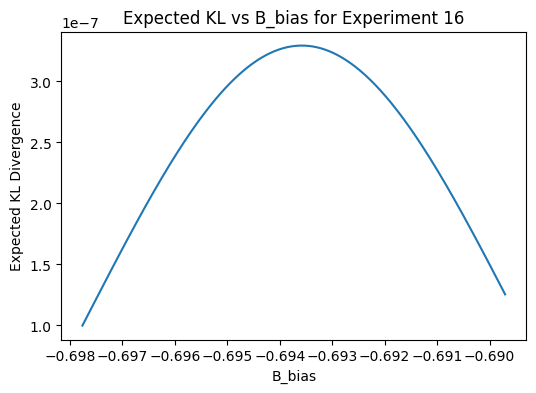

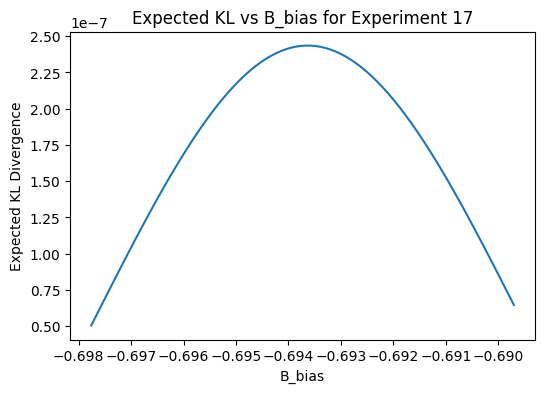

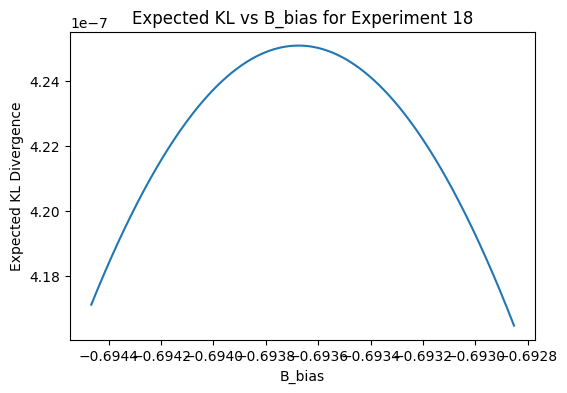

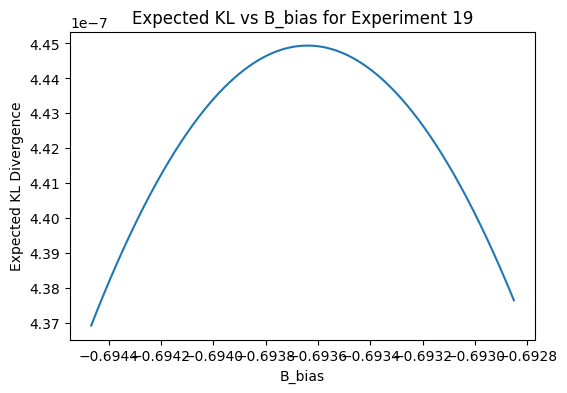

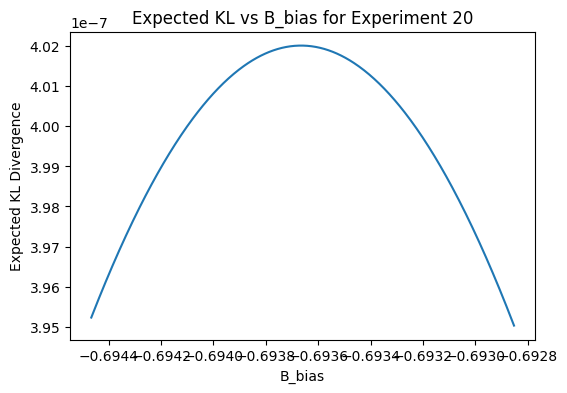

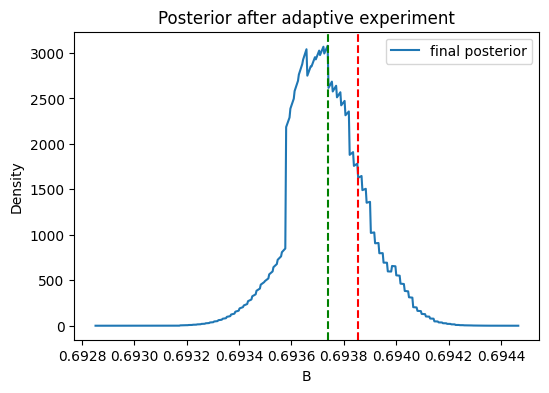

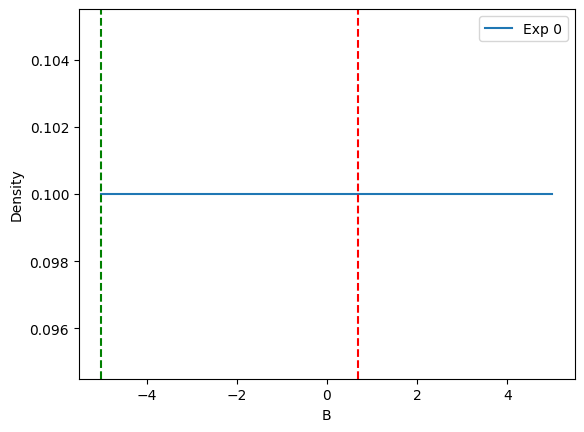

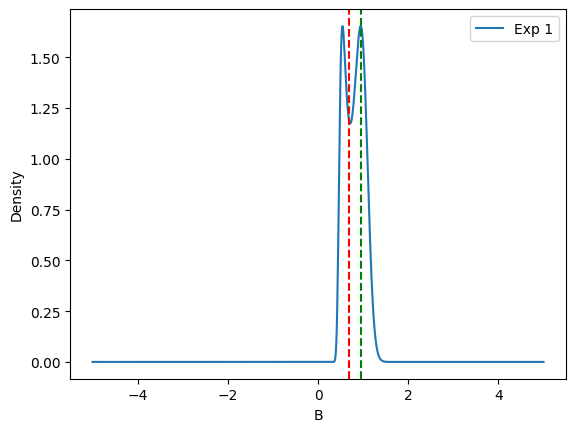

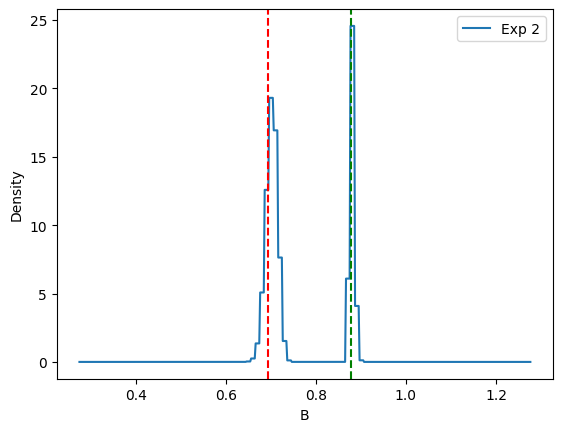

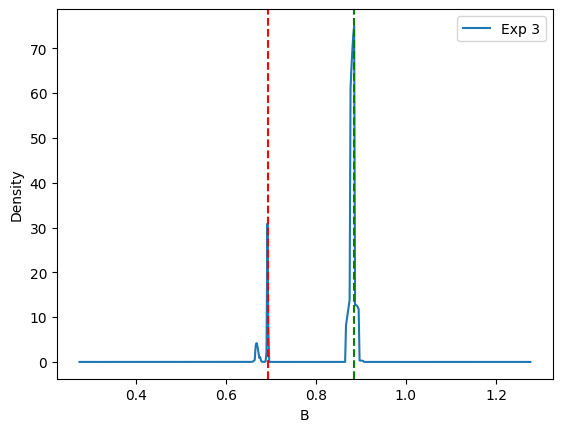

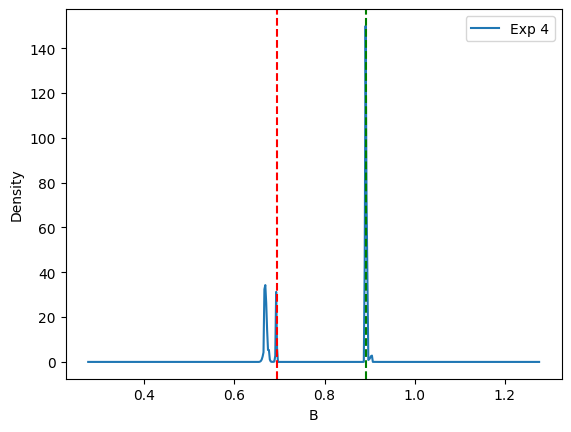

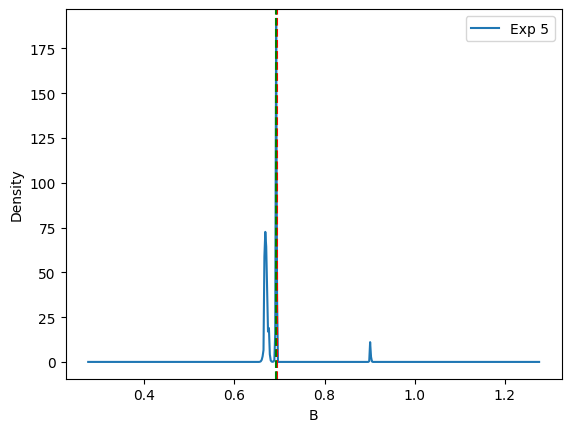

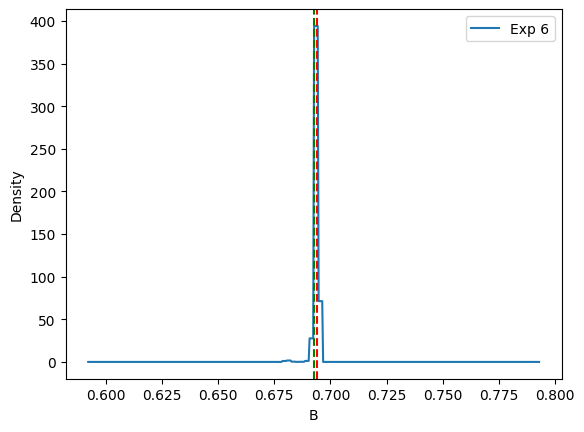

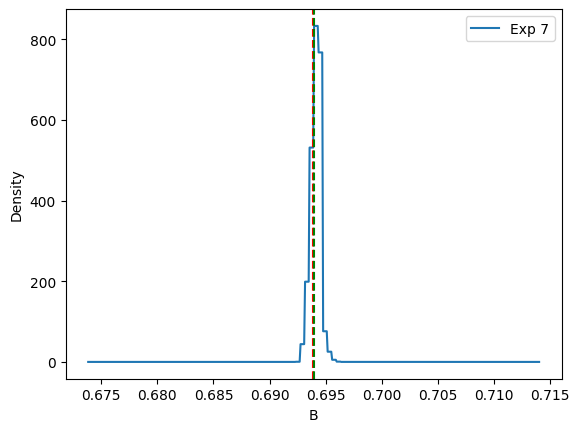

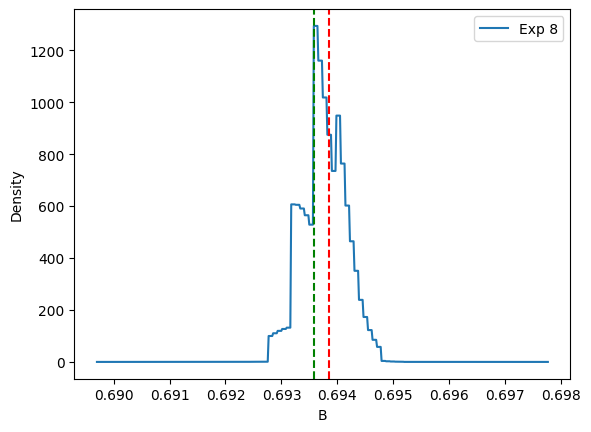

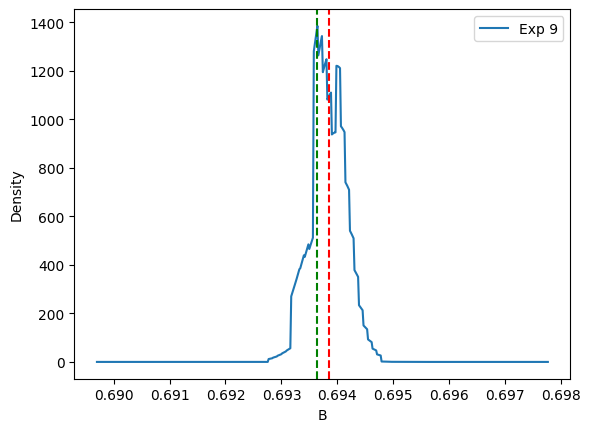

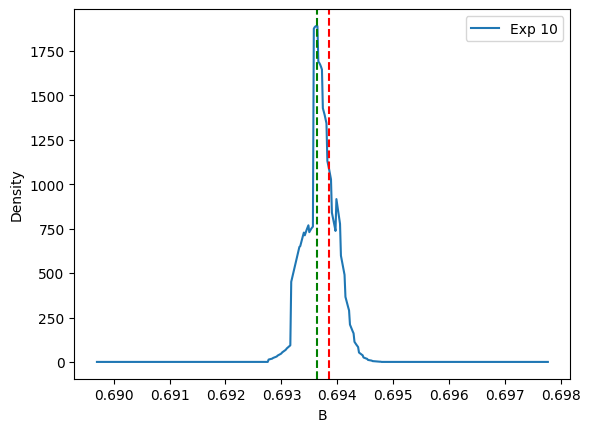

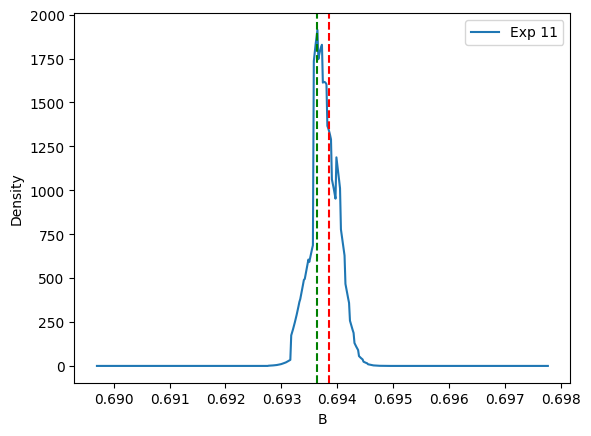

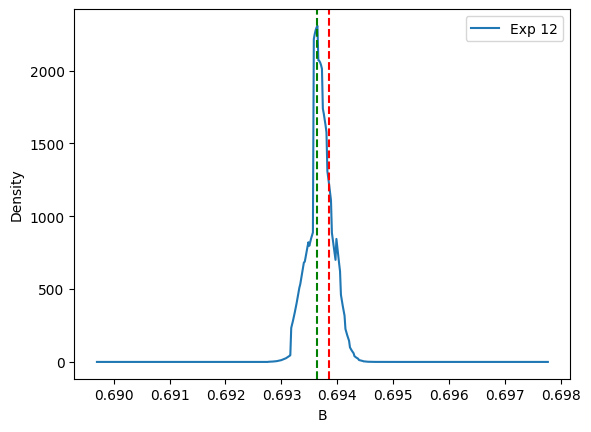

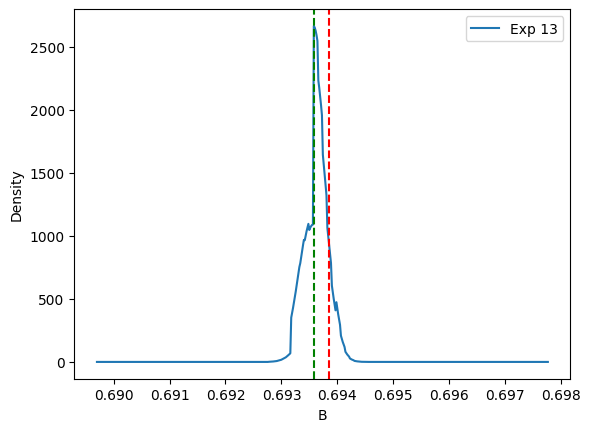

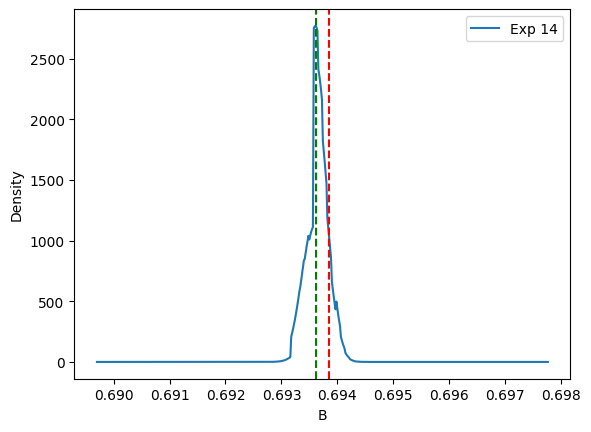

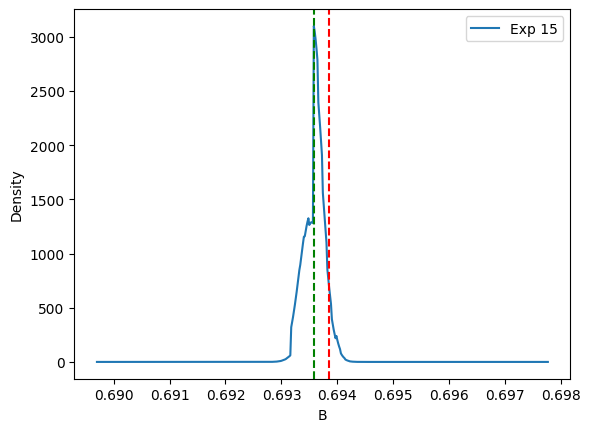

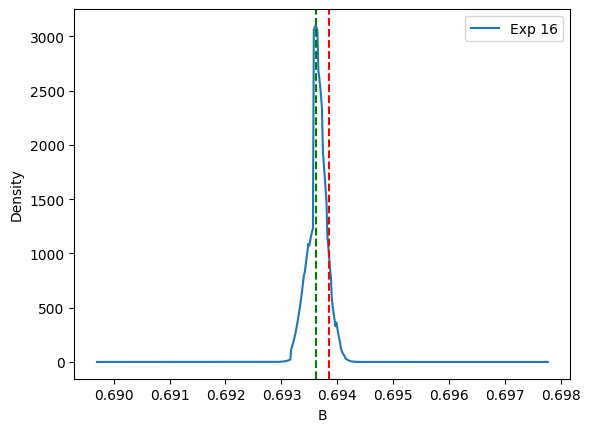

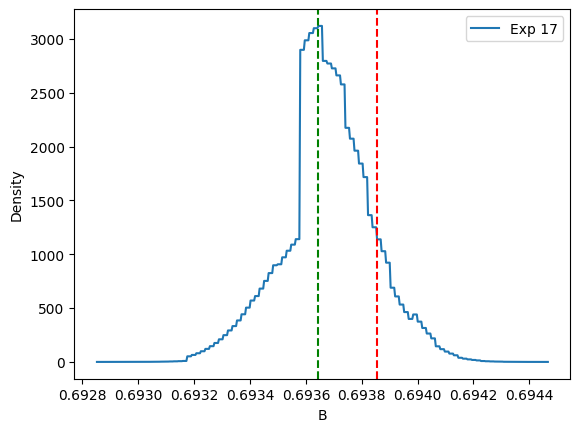

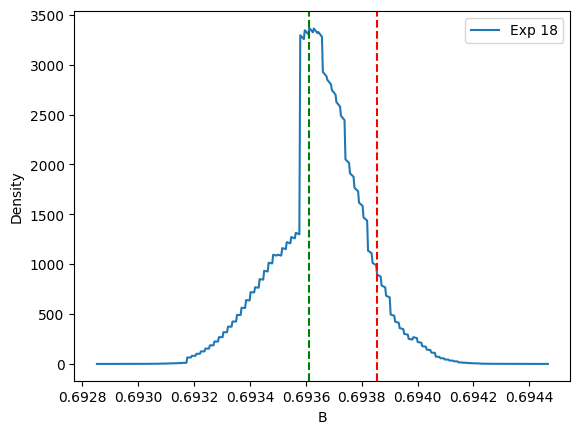

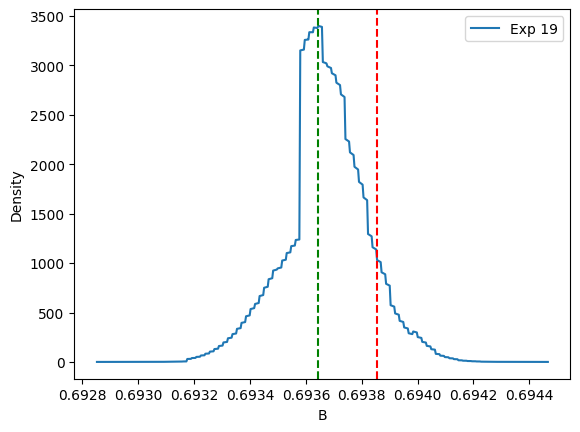

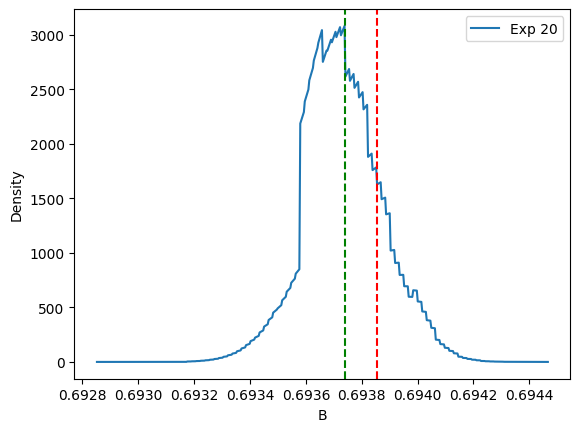

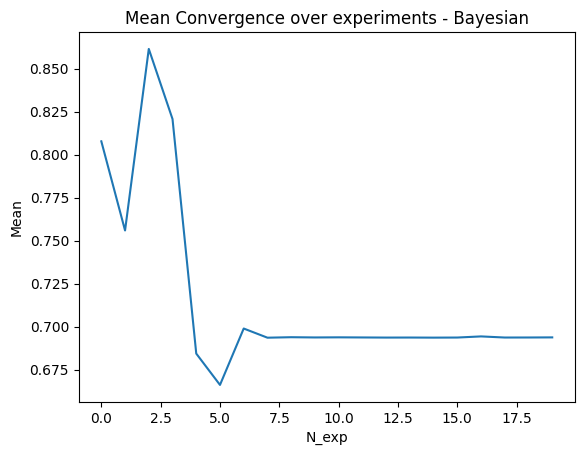

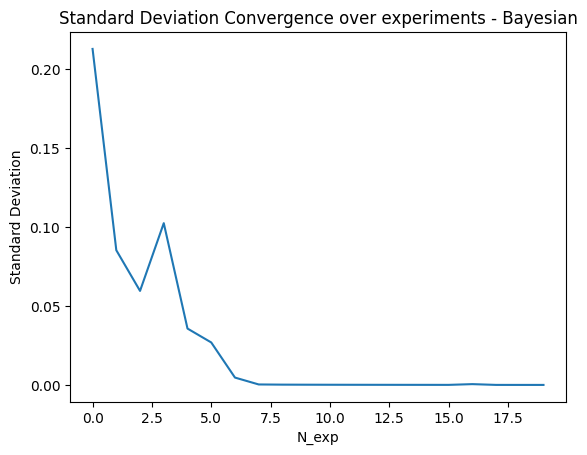

The Bayesian has promised.
Mean: 0.6937335512163175 , Mode: 0.6937384276256388 , StdDev: 0.00014112048880364942
-0.005005005005005048 : 7.462379903277681e-05 

-0.8258258258258258 : 7.08091196772763e-05 

-0.698544235618384 : 5.4013132315159717e-05 

-0.8830975263840994 : 5.958444146997007e-05 

-0.8951336105644723 : 4.7190536419294814e-05 

-0.6724660532275762 : 5.3631785721274924e-05 

-0.6935312105773268 : 1.5259942885887857e-05 

-0.6940540611303407 : 3.3498579077937056e-06 

-0.6937560283557427 : 2.3371403308018573e-06 

-0.6938367522925244 : 1.6114364317273005e-06 

-0.6936914492063173 : 1.1695762225238502e-06 

-0.693772173143099 : 9.232798028926482e-07 

-0.6936914492063173 : 6.982476304436152e-07 

-0.6936107252695356 : 5.358054330575746e-07 

-0.6936430148442483 : 4.181651704417628e-07 

-0.6935784356948229 : 3.292617629424996e-07 

-0.6936268700568919 : 2.4349799735660555e-07 

-0.6936737190590803 : 4.2509400398159516e-07 

-0.6936413647758011 : 4.4493490470029164e-07 

-0.6

<Figure size 640x480 with 0 Axes>

In [ ]:
bgrid, posteriors, biases, xpected_kl, mean_MAP, mode_MAP, stddev_MAP = run_experiment(
    N_exp=N_exp,
    B_true=B_unk,
    sigma_noise = 2e-5,
    #sigma=float("2e{j}".format(j = j)),
    sigma = 2e-5,
    B_range=(-5, 5),
    n_grid=1000,
    candidates=cp.linspace(-5, 5, 1000),
    Test = Test,
    Gamma=0.01
    )
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, bgrid[-1])
print(f"Final posterior area (should be ~1): {area:.6f}")


new_dir = "C:/Users/Dinesh/UGP/Tests/Toy_Model/Test_{Test}".format(Test=Test)
os.makedirs(new_dir, exist_ok=True)
save_path = os.path.join(new_dir, f'Final Posterior for Test {Test}.png'.format(Test))
plt.figure(figsize=(6, 4))
plt.plot(bgrid[-1], final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(B_unk, color="red", linestyle="--", label="True B")
plt.axvline(
    bgrid[-1][np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()
plt.savefig(save_path)


for i in range(len(posteriors)):
    line = plt.plot(bgrid[i], posteriors[i], label=f"Exp {i}")
    plt.legend(handles=line)
    plt.xlabel("B")
    plt.ylabel("Density")
    plt.axvline(B_unk, color="red", linestyle="--", label="True B")
    plt.axvline(
        bgrid[i][np.argmax(posteriors[i])],
        color="green",
        linestyle="--",
        label= f"MAP Estimate for {i}th iteration",
    )
    plt.show()

save_path = os.path.join(new_dir, f'Mean Convergence MAP Test {Test}.png'.format(Test))
plt.plot([i for i in range(N_exp)], mean_MAP, label=f"Mean Convergence")
plt.xlabel("N_exp")
plt.ylabel("Mean")
plt.title("Mean Convergence over experiments - Bayesian")
plt.show()
plt.savefig(save_path)

save_path = os.path.join(new_dir, f'Std Convergence MAP Test {Test}.png'.format(Test))
plt.plot([i for i in range(N_exp)], stddev_MAP, label=f"Standard Deviation Convergence")
plt.xlabel("N_exp")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Convergence over experiments - Bayesian")
plt.show()
plt.savefig(save_path)

if (mean_MAP[-1] -  B_unk)**2 < (Mean_MLE - B_unk)**2:
    print("The Bayesian has promised.")
else:
    print("Bruh, you got major skill issues")

print("Mean:", mean_MAP[-1], ", Mode:", mode_MAP[-1], ", StdDev:", stddev_MAP[-1])
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

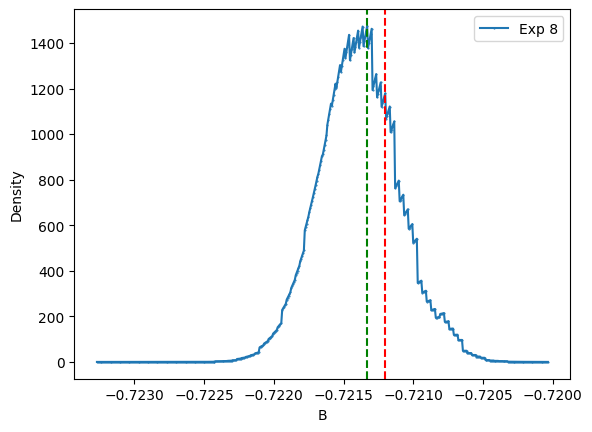

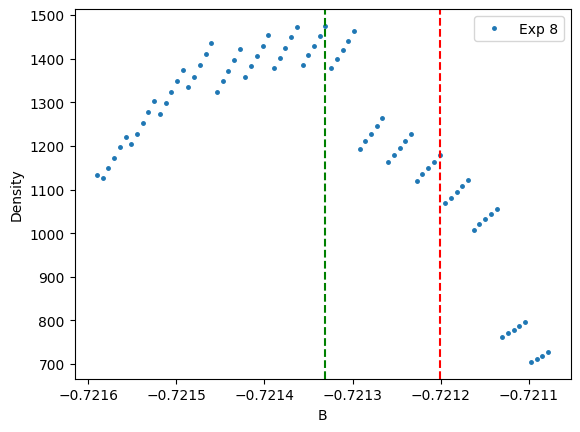

In [7]:
i=8
line = plt.plot(bgrid[i], posteriors[i],marker ='.',ms=1, label=f"Exp {i}")
plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(B_unk, color="red", linestyle="--", label="True B")
plt.axvline(
    bgrid[i][np.argmax(posteriors[i])],
    color="green",
    linestyle="--",
    label= f"MAP Estimate for {i}th iteration",
)
plt.show()
line = plt.plot(bgrid[i][np.argmax(posteriors[i]) - 40:np.argmax(posteriors[i]) + 40], posteriors[i][np.argmax(posteriors[i]) - 40:np.argmax(posteriors[i]) + 40], marker ='.',ms=5, linestyle='None', label=f"Exp {i}")
plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(B_unk, color="red", linestyle="--", label="True B")
plt.axvline(
    bgrid[i][np.argmax(posteriors[i])],
    color="green",
    linestyle="--",
    label= f"MAP Estimate for {i}th iteration",
)
plt.show()

For Saving Output Data

In [ ]:
# Convert lists to numpy arrays for efficient storage
# Replace variables with .get() if you are using CuPy arrays
results = {
    "bgrid": bgrid.get() if hasattr(bgrid, 'get') else bgrid,
    "posteriors": np.array([p.get() if hasattr(p, 'get') else p for p in posteriors]),
    "biases": np.array([x.get() if hasattr(x, 'get') else x for x in biases]),
    "xpected_kl": np.array([x.get() if hasattr(x, 'get') else x for x in xpected_kl]),
    "mean_MAP": np.array([x.get() if hasattr(x, 'get') else x for x in mean_MAP]),
    "mode_MAP": np.array([x.get() if hasattr(x, 'get') else x for x in mode_MAP]),
    "stddev_MAP": np.array([x.get() if hasattr(x, 'get') else x for x in stddev_MAP])
}

# Save into a single compressed file
np.savez_compressed(f"C:/Users/Dinesh/UGP/Tests/Toy_Model/Test_{Test}/Test_{Test}_results.npz", **results)
print("Simulation data saved successfully.")

Simulation data saved successfully.


For loading Output Data

In [ ]:
# Load the file
data = np.load(f"C:/Users/Dinesh/UGP/Tests/Toy_Model/Test_{Test}/Test_{Test}_results.npz")
B_grid = data["B_grid"]
posteriors = data["posteriors"]

In [ ]:
# TODO: compare with frequentist zero crossing approach: give quantitative estimate of:
# 1. amount of readings required for both
# 2. accuracy of estimate for both
# 3. inference time for both

# TODO
# 2. interpretability
# 3. adaptive simpson
# 4. mcmc
# 5. float64->float32
# 6. adaptive grid refinememtn
# 7. vectorisation of likelihood 